### Title : Perform sentiment analysis with a recurrent neural networks RNN

#### 1) Import Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


#### 2) Load Dataset

In [2]:
data_url = 'https://raw.githubusercontent.com/skillcate/sentiment-analysis-with-deep-neural-networks/main/a1_IMDB_Dataset.csv'
df = pd.read_csv(data_url)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.info()
print('\nMissing values:\n', df.isnull().sum())

print('\nClass distribution:')
print(df['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
 review       0
sentiment    0
dtype: int64

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


#### 3) Data Pre-processing

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)            # remove HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)         # keep letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()      # remove extra spaces
    return text

df['review_clean'] = df['review'].astype(str).apply(clean_text)

# Encode labels: positive -> 1, negative -> 0
label_map = {'negative': 0, 'positive': 1}
df['label'] = df['sentiment'].map(label_map)

df[['review', 'review_clean', 'sentiment', 'label']].head()

,review,review_clean,sentiment,label
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive,1
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive,1


In [5]:
# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['review_clean'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print('Train size:', X_train_text.shape[0])
print('Test size :', X_test_text.shape[0])

Train size: 40000
Test size : 10000


In [6]:
# Tokenization and sequence padding
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print('X_train_pad shape:', X_train_pad.shape)
print('X_test_pad shape :', X_test_pad.shape)

X_train_pad shape: (40000, 200)
X_test_pad shape : (10000, 200)


#### 4) Build RNN Model

In [7]:
EMBED_DIM = 128

model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, mask_zero=True),
    layers.LSTM(64, return_sequences=True, recurrent_dropout=0.2),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 200, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,369 (10.00 MB)

 Trainable params: 2,622,369 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Optional network graph visualization
try:
    keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, dpi=72)
    print('Model graph generated successfully (check notebook output/files).')
except Exception as e:
    print('Model graph could not be generated in this environment:', e)

You must install pydot (`pip install pydot`) for `plot_model` to work.
Model graph generated successfully (check notebook output/files).


#### 5) Train the Model

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
]

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 346ms/step - accuracy: 0.6920 - loss: 0.5655 - val_accuracy: 0.8324 - val_loss: 0.3894
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 319ms/step - accuracy: 0.8683 - loss: 0.3395 - val_accuracy: 0.8579 - val_loss: 0.3587
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 313ms/step - accuracy: 0.9117 - loss: 0.2410 - val_accuracy: 0.8439 - val_loss: 0.3839
Epoch 4/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 70s 281ms/step - accuracy: 0.9344 - loss: 0.1898 - val_accuracy: 0.8030 - val_loss: 0.6047


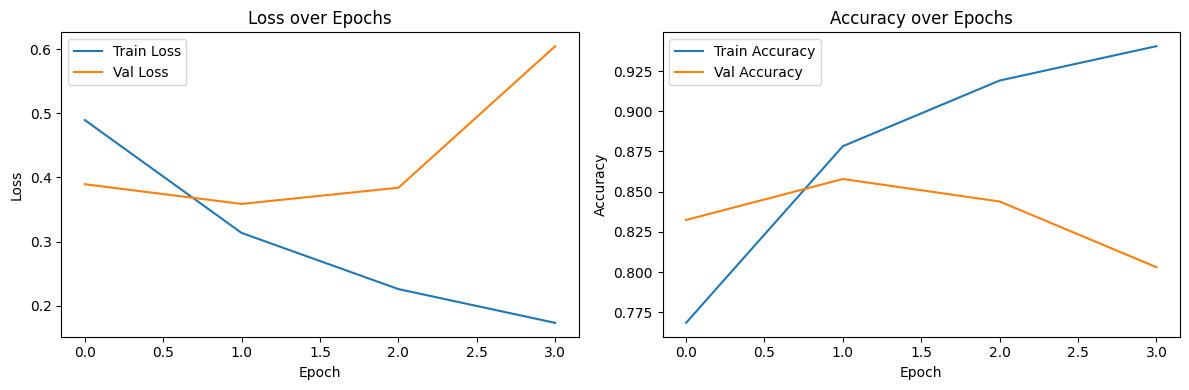

In [10]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Loss over Epochs')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[1].set_title('Accuracy over Epochs')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

#### 6) Evaluate Model

In [11]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss    : 0.3461
Test Accuracy: 0.8645


In [12]:
y_prob = model.predict(X_test_pad, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('Accuracy score:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive'], digits=4))

Accuracy score: 0.8645

Classification Report:

              precision    recall  f1-score   support

    negative     0.9100    0.8090    0.8565      5000
    positive     0.8281    0.9200    0.8716      5000

    accuracy                         0.8645     10000
   macro avg     0.8690    0.8645    0.8641     10000
weighted avg     0.8690    0.8645    0.8641     10000



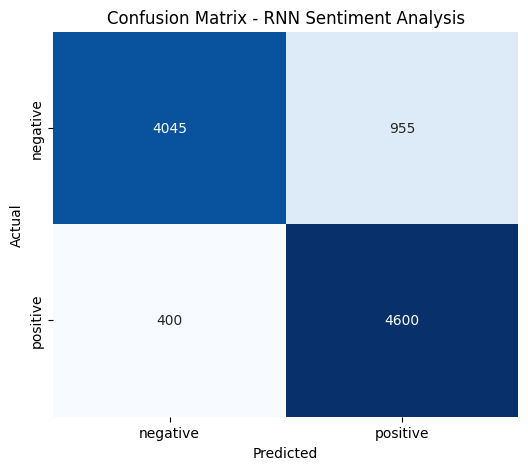

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion Matrix - RNN Sentiment Analysis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 7) Try Custom Predictions

In [14]:
def predict_sentiment(text):
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)[0][0]
    label = 'positive' if prob >= 0.5 else 'negative'
    return label, float(prob)

samples = [
    'This movie was fantastic, emotional and beautifully acted.',
    'The film was boring, too long, and not worth watching.'
]

for s in samples:
    label, prob = predict_sentiment(s)
    print(f'Text: {s}')
    print(f'Predicted Sentiment: {label} (probability of positive={prob:.4f})\n')

Text: This movie was fantastic, emotional and beautifully acted.
Predicted Sentiment: positive (probability of positive=0.8222)

Text: The film was boring, too long, and not worth watching.
Predicted Sentiment: negative (probability of positive=0.2307)

